# N - 아스피린 / 아세틸살리실산 단일제

In [1]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu
from statsmodels.stats.proportion import proportion_confint

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 및 아스피린/ASA 단일제 서브셋 추출 (아세트아미노펜/카페인 복합제는 제외)
df = pd.read_csv('FDA_adverse_events_final.csv', low_memory=False, parse_dates=['receive_date'])

def has_aspirin(d):
    d = str(d).upper()
    return ('ASPIRIN' in d or 'ACETYLSALICYLIC' in d or 'BUFFERIN' in d) and \
           not ('ACETAMINOPHEN' in d or 'PARACETAMOL' in d or 'CAFFEINE' in d)

mask_asp = (df['WHO_ATC'] == 'N') & df['suspect_drug'].apply(has_aspirin)
asa = df[mask_asp].copy()
df['group'] = np.where(mask_asp, '아스피린', '전체(나머지)')
colors_grp = {'아스피린': '#C44E52', '전체(나머지)': '#4C72B0'}
print(f'아스피린/ASA: {len(asa)}건 / 전체: {len(df)}건')

아스피린/ASA: 2185건 / 전체: 18273건


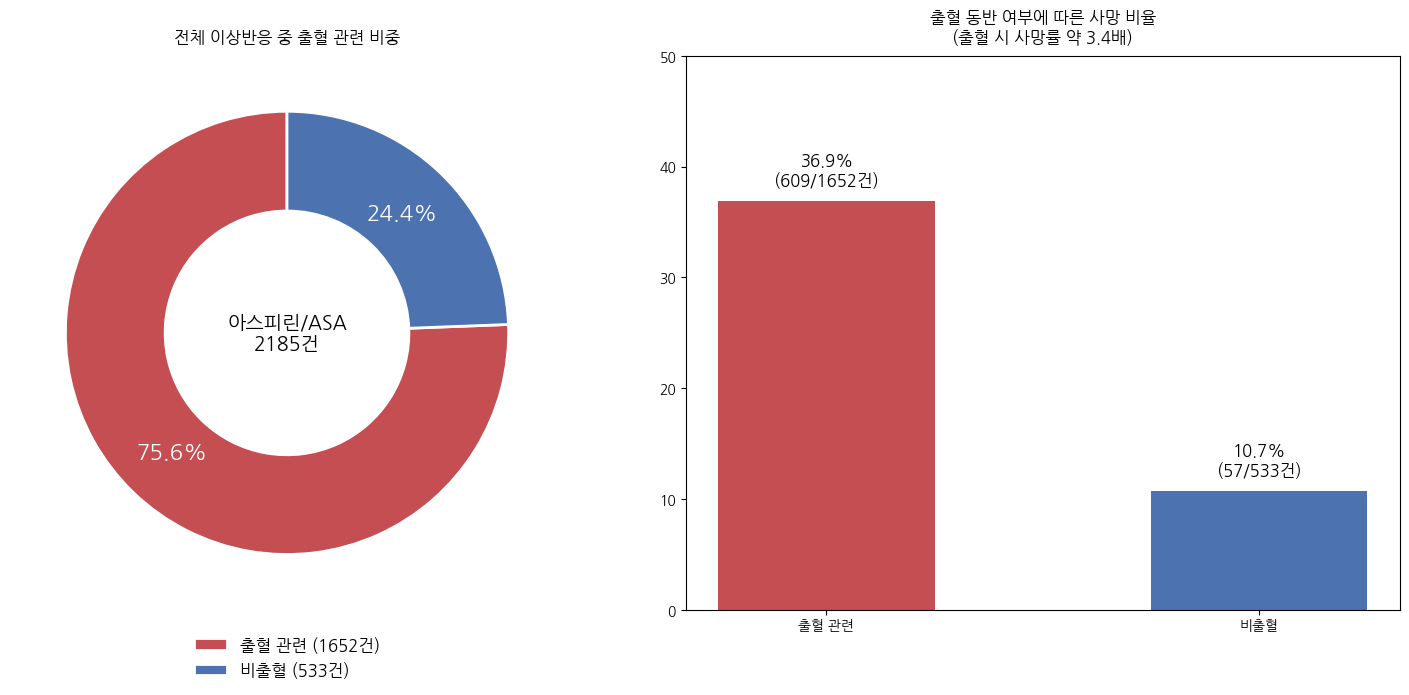

In [2]:
# 출혈 관련 이상반응 비중 및 출혈 동반 여부에 따른 사망률
hemorrhage_kw = ['haemorrhage', 'haematuria', 'epistaxis', 'anaemia', 'haematoma', 'haemorrhagic']
asa['has_bleed'] = asa['reactions'].fillna('').apply(lambda x: any(k.lower() in x.lower() for k in hemorrhage_kw))

n_bleed = asa['has_bleed'].sum()
n_total = len(asa)
n_nonbleed = n_total - n_bleed
died_bleed = asa.loc[asa['has_bleed'], 'is_fatal'].sum()
died_nonbleed = asa.loc[~asa['has_bleed'], 'is_fatal'].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

ax = axes[0]
ax.pie([n_bleed, n_nonbleed], colors=['#C44E52', '#4C72B0'], startangle=90,
       autopct=lambda pct: f'{pct:.1f}%', pctdistance=0.75,
       wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
       textprops=dict(fontsize=16, color='white', fontweight='bold'))
ax.text(0, 0, f'아스피린/ASA\n{n_total}건', ha='center', va='center', fontsize=14, fontweight='bold')
ax.legend([f'출혈 관련 ({n_bleed}건)', f'비출혈 ({n_nonbleed}건)'], loc='upper center',
          bbox_to_anchor=(0.5, -0.02), fontsize=12, frameon=False)
ax.set_title('전체 이상반응 중 출혈 관련 비중', pad=10)

ax = axes[1]
rates = [died_bleed / n_bleed * 100, died_nonbleed / n_nonbleed * 100]
counts_labels = [f'{died_bleed}/{n_bleed}건', f'{died_nonbleed}/{n_nonbleed}건']
ax.bar(range(2), rates, color=['#C44E52', '#4C72B0'], width=0.5)
for i, (r, c) in enumerate(zip(rates, counts_labels)):
    ax.text(i, r + 1.5, f'{r:.1f}%\n({c})', ha='center', fontsize=12, fontweight='bold')
ax.set_xticks(range(2)); ax.set_xticklabels(['출혈 관련', '비출혈'])
ax.set_ylim(0, 50)
ax.set_title(f'출혈 동반 여부에 따른 사망 비율\n(출혈 시 사망률 약 {rates[0]/rates[1]:.1f}배)', pad=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_282/48927717.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(age_order_adult, rotation=15)


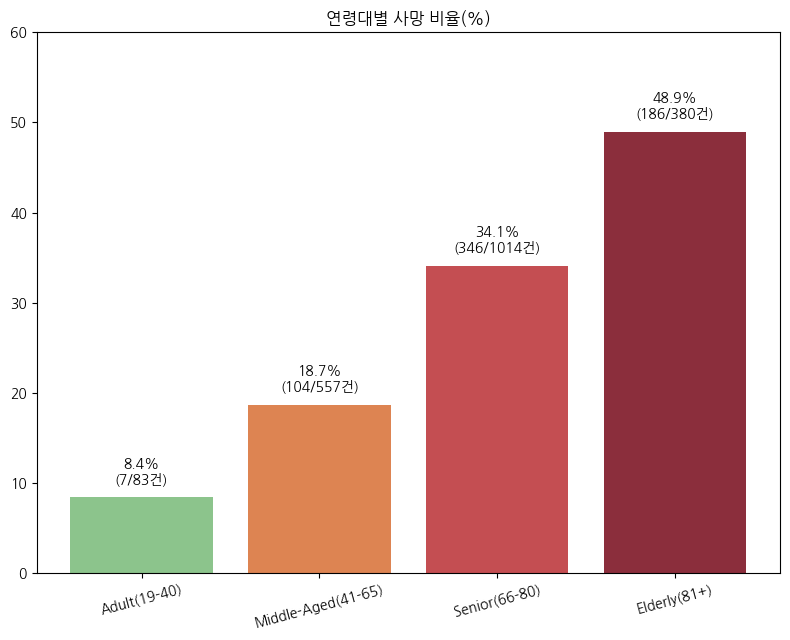

In [3]:
# 연령대별 사망률 (성인 이상)
age_order_adult = ['Adult(19-40)', 'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)']
sub = asa[asa['age_group'].isin(age_order_adult)]

summary = sub.groupby('age_group').agg(건수=('report_id', 'count'), 사망건수=('is_fatal', 'sum')).reindex(age_order_adult)
summary['사망률'] = summary['사망건수'] / summary['건수'] * 100

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.bar(age_order_adult, summary['사망률'], color=['#8CC48C', '#DD8452', '#C44E52', '#8B2E3C'])
for i, (r, d_, t) in enumerate(zip(summary['사망률'], summary['사망건수'], summary['건수'])):
    ax.text(i, r + 1.5, f'{r:.1f}%\n({d_}/{t}건)', ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, 60)
ax.set_title('연령대별 사망 비율(%)')
ax.set_xticklabels(age_order_adult, rotation=15)

plt.tight_layout()
plt.show()

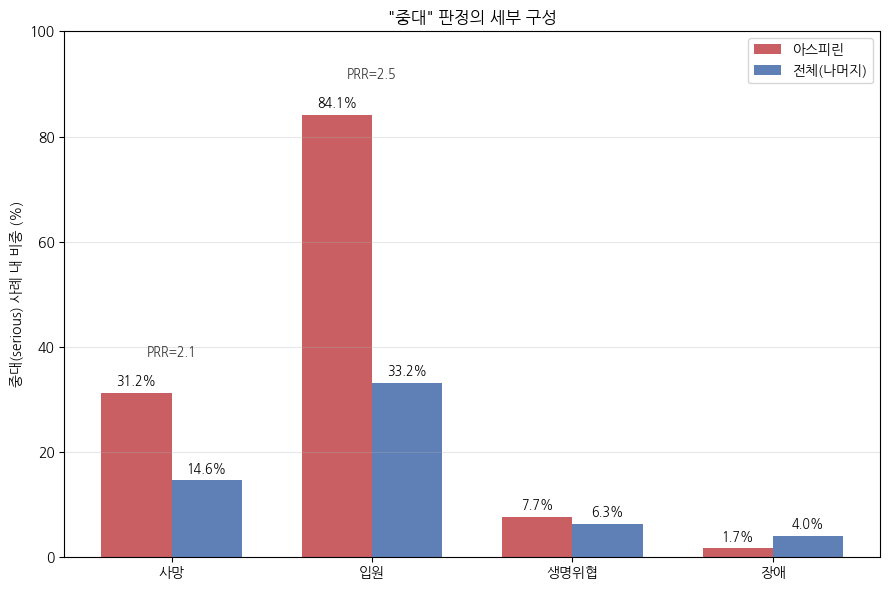

group  아스피린  전체(나머지)
flag                
사망     31.2     14.6
생명위협    7.7      6.3
입원     84.1     33.2
장애      1.7      4.0

PRR: {'사망': np.float64(2.14), '입원': np.float64(2.53), '생명위협': np.float64(1.22), '장애': np.float64(0.42)}


In [4]:
# '중대(serious)' 판정의 세부 구성 (사망/입원/생명위협/장애 비중 + PRR)
flag_cols = ['is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling']
flag_labels = ['사망', '입원', '생명위협', '장애']
serious = df[df['serious'] == 'Yes']

rows = []
for grp in ['아스피린', '전체(나머지)']:
    sub_s = serious[serious['group'] == grp]
    n1 = len(sub_s)
    for col, label in zip(flag_cols, flag_labels):
        k = sub_s[col].sum()
        rows.append({'group': grp, 'flag': label, 'n': n1, 'k': k, 'pct': k/n1*100})

res = pd.DataFrame(rows)

rest_s = serious[serious['group'] == '전체(나머지)']
asp_s = serious[serious['group'] == '아스피린']
prr_dict = {}
for col, label in zip(flag_cols, flag_labels):
    a, n1 = asp_s[col].sum(), len(asp_s)
    c, n2 = rest_s[col].sum(), len(rest_s)
    prr_dict[label] = (a/n1) / (c/n2)

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(flag_labels)); width = 0.35

for i, grp in enumerate(['아스피린', '전체(나머지)']):
    offset = (i - 0.5) * width
    sub_g = res[res['group'] == grp].set_index('flag').loc[flag_labels]
    ax.bar(x + offset, sub_g['pct'], width, label=grp, color=colors_grp[grp], alpha=0.9)
    for xi, v in zip(x + offset, sub_g['pct']):
        ax.text(xi, v + 1.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

for idx, label in enumerate(['사망', '입원']):
    ax.annotate(f'PRR={prr_dict[label]:.1f}', xy=(idx, res[res['flag']==label]['pct'].max() + 7),
                ha='center', fontsize=9, fontweight='bold', color='#333')

ax.set_xticks(x); ax.set_xticklabels(flag_labels)
ax.set_ylabel('중대(serious) 사례 내 비중 (%)')
ax.set_ylim(0, 100)
ax.set_title('"중대" 판정의 세부 구성')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(res.pivot(index='flag', columns='group', values='pct').round(1))
print('\nPRR:', {k: round(v,2) for k,v in prr_dict.items()})

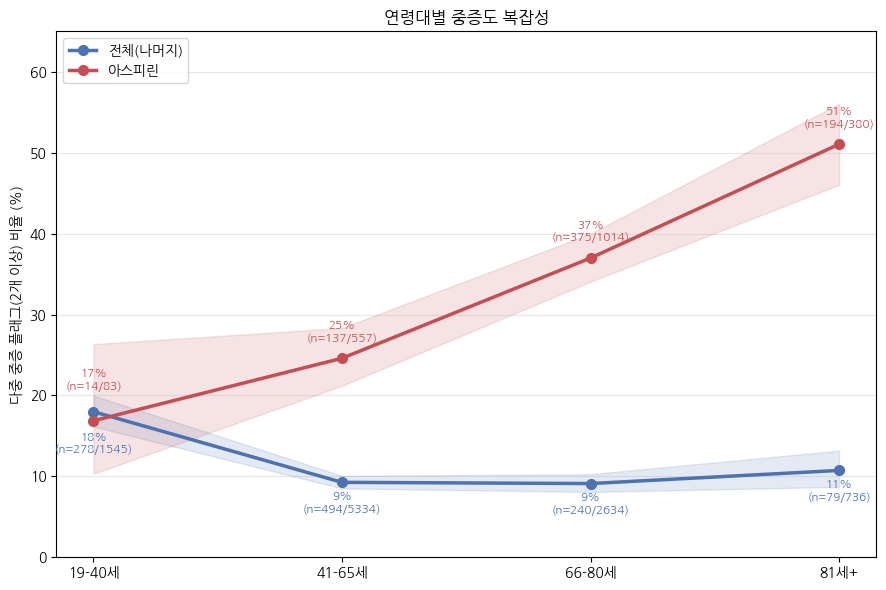

  group                age    n   k      rate        lo        hi
   아스피린       Adult(19-40)   83  14 16.867470 10.322081 26.344114
   아스피린 Middle-Aged(41-65)  557 137 24.596050 21.201644 28.338463
   아스피린      Senior(66-80) 1014 375 36.982249 34.065211 39.997547
   아스피린       Elderly(81+)  380 194 51.052632 46.041212 56.042982
전체(나머지)       Adult(19-40) 1545 278 17.993528 16.158212 19.987609
전체(나머지) Middle-Aged(41-65) 5334 494  9.261342  8.512433 10.068888
전체(나머지)      Senior(66-80) 2634 240  9.111617  8.071364 10.270961
전체(나머지)       Elderly(81+)  736  79 10.733696  8.697804 13.177350


In [5]:
# 연령대별 다중 중증 플래그(2개 이상) 비율 (Wilson 95% CI)
flags = ['is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling']
df['n_flags'] = df[flags].sum(axis=1)
df['multi_flag'] = df['n_flags'] >= 2

age_labels_adult = ['19-40세', '41-65세', '66-80세', '81세+']
rows = []
for grp in ['아스피린', '전체(나머지)']:
    sub_g = df[df['group'] == grp]
    for age in age_order_adult:
        s = sub_g[sub_g['age_group'] == age]
        n = len(s)
        k = s['multi_flag'].sum()
        lo, hi = proportion_confint(k, n, method='wilson')
        rows.append({'group': grp, 'age': age, 'n': n, 'k': k, 'rate': k/n*100, 'lo': lo*100, 'hi': hi*100})

res_age = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(age_order_adult))

for grp in ['전체(나머지)', '아스피린']:
    sub_g = res_age[res_age['group'] == grp].set_index('age').loc[age_order_adult]
    ax.plot(x, sub_g['rate'], marker='o', linewidth=2.5, markersize=7, color=colors_grp[grp], label=grp)
    ax.fill_between(x, sub_g['lo'], sub_g['hi'], color=colors_grp[grp], alpha=0.15)
    for xi, row in zip(x, sub_g.itertuples()):
        dy = (22 if grp == '아스피린' else -30) if xi == 0 else ((-22 if grp == '전체(나머지)' else 12))
        ax.annotate(f'{row.rate:.0f}%\n(n={row.k}/{row.n})', (xi, row.rate), textcoords='offset points',
                    xytext=(0, dy), ha='center', fontsize=8.5, color=colors_grp[grp], fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(age_labels_adult)
ax.set_ylabel('다중 중증 플래그(2개 이상) 비율 (%)')
ax.set_ylim(0, 65)
ax.set_title('연령대별 중증도 복잡성')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print(res_age.to_string(index=False))

분석 대상: 1168건 (배치 이상치 1276건 제외)

[Kruskal-Wallis] 연령 vs 심각도복합도: p = 3.44e-09
[카이제곱] 뇌출혈 비중 vs 심각도복합도: p = 0.016


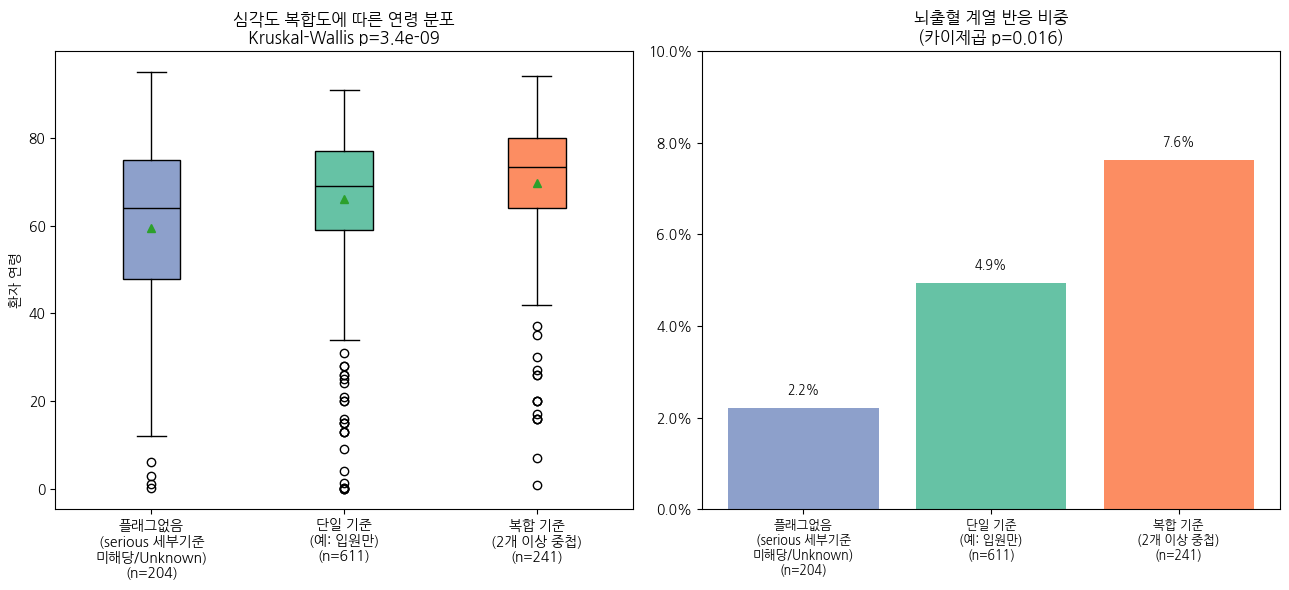

In [6]:
# 아스피린/ASA 심각도 복합도(Severity Complexity) 분석
def first_segment(s):
    return '' if pd.isna(s) else s.split(';')[0]

aspirin_pat = re.compile(r'ASPIRIN|ACETYLSALICYLIC', re.I)
df['first_seg'] = df['suspect_drug'].apply(first_segment)
mask_first = df['first_seg'].apply(lambda x: bool(aspirin_pat.search(x)))
sub_first = df[mask_first].copy()

# 배치성 이상치 제외 (2020년 전체, 2022년 7월)
sub_first['year'] = sub_first['receive_date'].dt.year
sub_first['month'] = sub_first['receive_date'].dt.month
batch = ((sub_first['year'] == 2020) | ((sub_first['year'] == 2022) & (sub_first['month'] == 7)))
clean = sub_first[~batch].copy()
print(f'분석 대상: {len(clean)}건 (배치 이상치 {batch.sum()}건 제외)')

# 심각도 복합도: 4개 세부기준(사망/입원/생명위협/장애) 중 동시 해당 개수
clean['n_flags'] = clean[['is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling']].sum(axis=1)

def sevgroup(n):
    if n == 0: return '플래그없음\n(serious 세부기준\n미해당/Unknown)'
    if n == 1: return '단일 기준\n(예: 입원만)'
    return '복합 기준\n(2개 이상 중첩)'

clean['sev_group'] = clean['n_flags'].apply(sevgroup)
order = ['플래그없음\n(serious 세부기준\n미해당/Unknown)', '단일 기준\n(예: 입원만)', '복합 기준\n(2개 이상 중첩)']

clean['age_num'] = pd.to_numeric(clean['patient_age_years'], errors='coerce')
clean['is_cns_bleed'] = clean['primary_reaction'].str.contains(
    'cerebral|subarachnoid|intracranial|arteriovenous', case=False, na=False)

groups = [clean[clean.sev_group == g]['age_num'].dropna() for g in order]
stat, p_age = kruskal(*groups)
print(f'\n[Kruskal-Wallis] 연령 vs 심각도복합도: p = {p_age:.2e}')

ct = pd.crosstab(clean['sev_group'], clean['is_cns_bleed'])
chi2, p_cns, dof, _ = chi2_contingency(ct)
print(f'[카이제곱] 뇌출혈 비중 vs 심각도복합도: p = {p_cns:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
colors12 = ['#8DA0CB', '#66C2A5', '#FC8D62']

ns = [len(g) for g in groups]
bp = axes[0].boxplot(groups, tick_labels=[f'{o}\n(n={n})' for o, n in zip(order, ns)],
                      showmeans=True, patch_artist=True, medianprops=dict(color='black'))
for patch, c in zip(bp['boxes'], colors12):
    patch.set_facecolor(c)
axes[0].set_ylabel('환자 연령')
axes[0].set_title(f'심각도 복합도에 따른 연령 분포\nKruskal-Wallis p={p_age:.1e}')

cns_rate = clean.groupby('sev_group')['is_cns_bleed'].mean().reindex(order) * 100
bars = axes[1].bar(range(3), cns_rate.values, color=colors12)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels([f'{o}\n(n={n})' for o, n in zip(order, ns)], fontsize=9)
axes[1].set_ylim(0, 10)
axes[1].set_title(f'뇌출혈 계열 반응 비중\n(카이제곱 p={p_cns:.3f})')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for b, v in zip(bars, cns_rate.values):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()